# Inference-Time Optimization of Prompt Embeddings in Diffusion Models: A Comparison of sep-CMA-ES and Adam

This notebook allows the reproduction of the paper's experiments. It implements the inference-time optimization pipeline for SDXL Turbo, where prompt embeddings are optimized under a weighted objective that combines LAION Aesthetic Predictor V2 and CLIPScore. 

The notebook follows the paper’s experimental setting to compare the gradient-based Adam optimizer with the evolutionary sep-CMA-ES across different trade-offs between aesthetic quality and prompt-image alignment, enabling the reproduction of the main quantitative results and example outputs reported in the paper.


In [1]:
# Initial setup for notebook execution, ensuring that the repository root is in the Python path for imports.
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
if repo_root.name == 'notebook':
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.utils import aggregate_results, create_method_comparison_plots, make_config, run_batch_experiment


In [2]:
batch_config = make_config(
    # General settings
    optimization_method= "cmaes", # Optimization method: 'cmaes' for sep-CMA-ES or 'adam' for Adam.
    seed= 42, # Random seed for reproducibility across prompt embedding optimization runs.
    cuda= 2, # CUDA device index used for all computations. Set "cpu" to run on CPU.
    num_inference_steps= 1, # Number of denoising steps used by SDXL Turbo during image generation.
    guidance_scale= 0.0, # Classifier-free guidance scale; 0.0 keeps the setup in the intended turbo regime.
    height= 512, # Image height in pixels for generated images.
    width= 512, # Image width in pixels for generated images.
    aesthetic_score_weight= 0.5, # Weight for the aesthetic score in the combined reward function.
    clip_score_weight= 0.5, # Weight for the CLIP score in the combined reward function.
    max_aesthetic_score= 10.0, # Maximum possible aesthetic score from the predictor, used for rescaling.
    max_clip_score= 0.5, # Maximum possible CLIP score from the predictor, used for rescaling.
    model_id= "stabilityai/sdxl-turbo", # Hugging Face model identifier for the diffusion backbone.
    prompt_per_category= 3, # Number of distinct prompts sampled per category for batch optimization.
    prompt_sample_seed= 42, # Random seed used for sampling prompts from the pool of available prompts.
    results_folder=str(repo_root / 'results' / 'batch_comparison'), # Folder where results of the batch experiment will be saved.
    # sep-CMA-ES specific parameters:
    num_generations=5,
    pop_size= 5,
    sigma= 0.4,
    save_gens= False,
    # Adam specific parameters:
    num_iterations= 20,
    adam_lr= 1e-4,
    adam_weight_decay= 0.0,
    adam_eps= 1e-8,
    adam_beta1= 0.9,
    adam_beta2= 0.999,
    # Time limit for the optimization process in seconds.
    time_limit_seconds=None, # Set to None to follow the number of generations/iterations.
)


In [6]:
run_folders = run_batch_experiment(
    batch_config,
    methods=('cmaes', 'adam'),
    seeds=[42], # List of random seeds to run for each method, allowing for multiple runs to assess variability.
)
run_folders


Running cmaes | seed=42 | prompt=happiness
Generation 1/5
Generation 1/5: Max fitness=0.5266, Max aesthetic=6.8911, Max clip=0.1821, ETA=7s
Generation 2/5
Generation 2/5: Max fitness=0.5458, Max aesthetic=7.2455, Max clip=0.1836, ETA=6s
Generation 3/5
Generation 3/5: Max fitness=0.5410, Max aesthetic=7.3218, Max clip=0.1833, ETA=4s
Generation 4/5
Generation 4/5: Max fitness=0.5481, Max aesthetic=7.4463, Max clip=0.1834, ETA=2s
Generation 5/5
Generation 5/5: Max fitness=0.5535, Max aesthetic=7.3105, Max clip=0.1890, ETA=0s
Running cmaes | seed=42 | prompt=metal
Generation 1/5
Generation 1/5: Max fitness=0.5355, Max aesthetic=7.0828, Max clip=0.1888, ETA=6s
Generation 2/5
Generation 2/5: Max fitness=0.5119, Max aesthetic=6.8889, Max clip=0.1979, ETA=5s
Generation 3/5
Generation 3/5: Max fitness=0.5393, Max aesthetic=7.2932, Max clip=0.1973, ETA=3s
Generation 4/5
Generation 4/5: Max fitness=0.5441, Max aesthetic=7.0906, Max clip=0.1977, ETA=1s
Generation 5/5
Generation 5/5: Max fitness=0.

['/home/posgrad/phd2025/dneto/ope_experiments/results/batch_comparison/sepcmaes_laionv2_sdxl_sdxlturbo_seed42_p1',
 '/home/posgrad/phd2025/dneto/ope_experiments/results/batch_comparison/sepcmaes_laionv2_sdxl_sdxlturbo_seed42_p2',
 '/home/posgrad/phd2025/dneto/ope_experiments/results/batch_comparison/sepcmaes_laionv2_sdxl_sdxlturbo_seed42_p3',
 '/home/posgrad/phd2025/dneto/ope_experiments/results/batch_comparison/sepcmaes_laionv2_sdxl_sdxlturbo_seed42_p4',
 '/home/posgrad/phd2025/dneto/ope_experiments/results/batch_comparison/sepcmaes_laionv2_sdxl_sdxlturbo_seed42_p5',
 '/home/posgrad/phd2025/dneto/ope_experiments/results/batch_comparison/sepcmaes_laionv2_sdxl_sdxlturbo_seed42_p6',
 '/home/posgrad/phd2025/dneto/ope_experiments/results/batch_comparison/sepcmaes_laionv2_sdxl_sdxlturbo_seed42_p7',
 '/home/posgrad/phd2025/dneto/ope_experiments/results/batch_comparison/sepcmaes_laionv2_sdxl_sdxlturbo_seed42_p8',
 '/home/posgrad/phd2025/dneto/ope_experiments/results/batch_comparison/sepcmaes_

In [3]:
summary = aggregate_results(batch_config['results_folder'])
summary


,run_dir,method,prompt,category,final_aesthetic_score,final_clip_score,final_objective,elapsed_time
0,adam_laionv2_sdxl_sdxlturbo_seed42_p1,adam,happiness,Abstract,6.621820,0.176858,0.507949,19.736542
1,adam_laionv2_sdxl_sdxlturbo_seed42_p10,adam,an oil surrealist painting of a dreamworld on ...,Arts,6.677247,0.417068,0.750931,19.580605
2,adam_laionv2_sdxl_sdxlturbo_seed42_p11,adam,"A raccoon wearing formal clothes, wearing a to...",Arts,6.187561,0.344626,0.654004,21.274002
3,adam_laionv2_sdxl_sdxlturbo_seed42_p12,adam,an abstract painting of a tree and a building,Arts,6.026496,0.342592,0.643917,18.527702
4,adam_laionv2_sdxl_sdxlturbo_seed42_p13,adam,The Statue of Liberty,World Knowledge,6.112577,0.243462,0.549091,19.492086
...,...,...,...,...,...,...,...,...
68,sepcmaes_laionv2_sdxl_sdxlturbo_seed42_p5,sepcmaes,an antique car by a beach,Vehicles,6.284878,0.301605,0.613318,10.297818
69,sepcmaes_laionv2_sdxl_sdxlturbo_seed42_p6,sepcmaes,a drop-top sports car coming around a bend in ...,Vehicles,5.896193,0.249445,0.530477,10.197164
70,sepcmaes_laionv2_sdxl_sdxlturbo_seed42_p7,sepcmaes,a cube made of porcupine,Illustrations,5.866376,0.326889,0.613483,10.270229
71,sepcmaes_laionv2_sdxl_sdxlturbo_seed42_p8,sepcmaes,a musical note,Illustrations,5.735221,0.267999,0.554282,10.276153


In [4]:
plot_paths = create_method_comparison_plots(batch_config['results_folder'])
plot_paths


{'aesthetic': '/home/posgrad/phd2025/dneto/ope_experiments/results/batch_comparison/aesthetic_comparison.png',
 'clip': '/home/posgrad/phd2025/dneto/ope_experiments/results/batch_comparison/clip_comparison.png',
 'objective': '/home/posgrad/phd2025/dneto/ope_experiments/results/batch_comparison/objective_comparison.png'}

### Aesthetic Score Evolution by Method

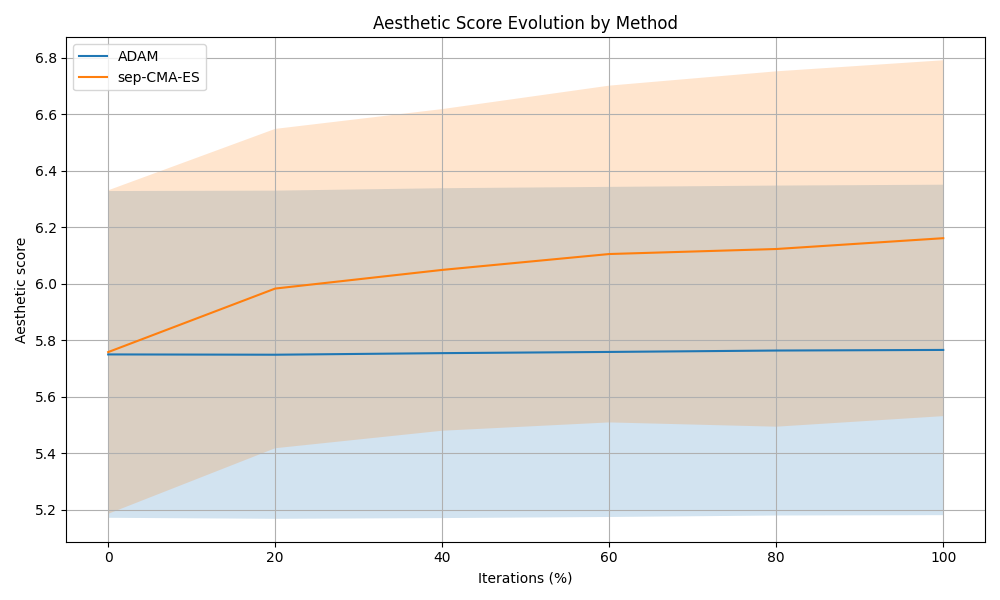

### CLIP Score Evolution by Method

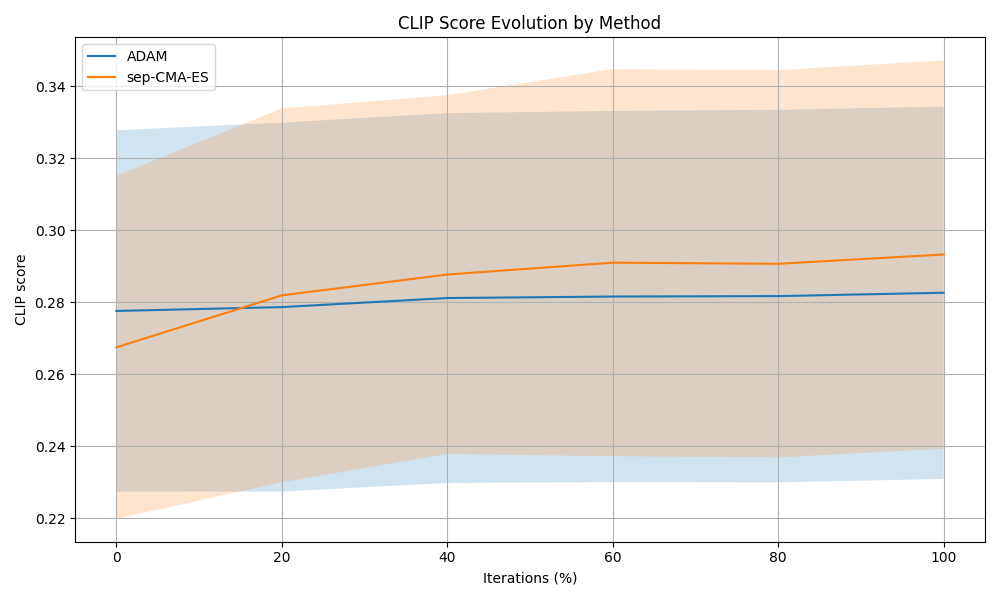

### Combined Objective Evolution by Method

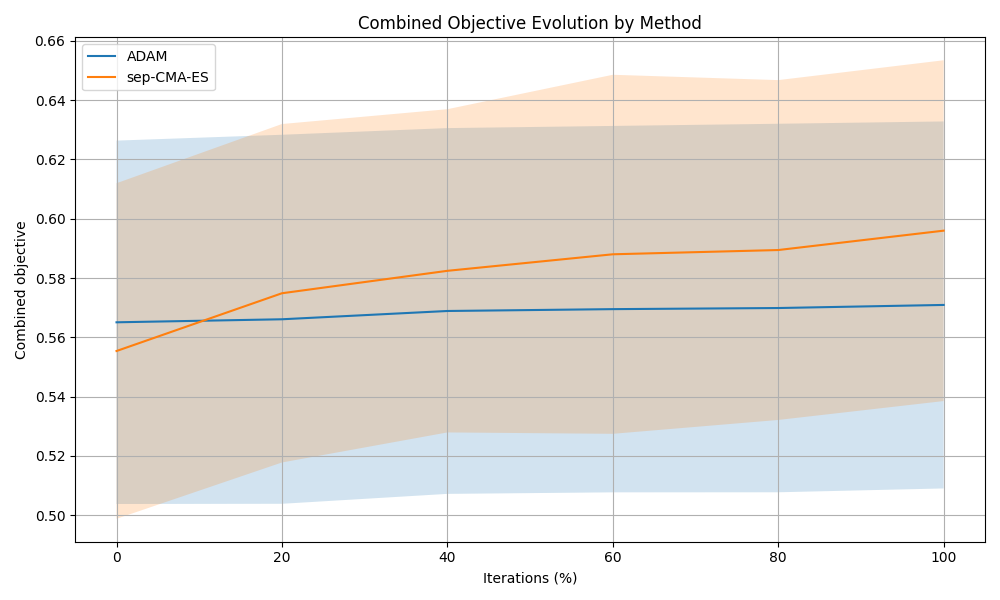

In [5]:
from IPython.display import Image, Markdown, display

display(Markdown('### Aesthetic Score Evolution by Method'))
display(Image(filename=plot_paths['aesthetic']))
display(Markdown('### CLIP Score Evolution by Method'))
display(Image(filename=plot_paths['clip']))
display(Markdown('### Combined Objective Evolution by Method'))
display(Image(filename=plot_paths['objective']))
